# 8장 실습 — 하이퍼파라미터 민감도

7장이 행동 복제를 주 정책으로 세웠다. 이 노트북은 그 복제 정책의 **손잡이 셋**을 훑는다 — 학습률, 학습 스텝 수, 신경망 폭. 한 번에 하나만 바꾸고 나머지는 1부부터 써 온 기본값(학습률 10⁻³, 4,000 스텝, 폭 64)에 둔다.

재는 것은 셋이다.

1. **민감도** — 손잡이마다 성적이 얼마나 움직이는가. 그 움직임이 **시드 편차보다 큰가**
2. **지연 민감도** — 배포 조건에 더해 지연을 두 주기로 늘린 조건에서도 잰다. 3부에서 고른 설정이 5부의 지연 문제를 바꾸는지 보기 위해서다
3. **한계 수익** — 훑기에 쓴 계산을 시연을 두 배로 모으는 데 썼다면 어땠는가

끝에서 `policy/hparams.json` 을 남긴다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="sorting_cell">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="part" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
SEP, BX = .10, .28                      # 적재함 위치 (m)
MODEL = mujoco.MjModel.from_xml_string(XML)


def bin_xy(k):
    """A형(k=0)은 왼쪽, B형(k=1)은 오른쪽 적재함이다"""
    return np.array([BX, (1 - 2 * k) * SEP])


class Cell:
    """평면 분류 셀 — 부품을 종류에 맞는 칸으로 민다"""

    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.k = np.zeros(n, int)
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        self.k[i] = self.rng.integers(0, 2)
        jit = self.rng.uniform(-.03, .03, 2)
        self.g[i] = bin_xy(self.k[i]) + jit
        b = np.array([bx, by])
        v = self.g[i] - b
        d.qpos[7:9] = b - v / np.linalg.norm(v) * .09
        mujoco.mj_forward(self.m, d)
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.zeros((self.n, 10), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = (self.g[i] - b) * 10.
            o[i, 2:4] = d.qvel[0:2] * 10.
            o[i, 4:6] = (b - d.qpos[7:9]) * 10.
            o[i, 6:8] = d.qvel[6:8] * 10.
            o[i, 8 + self.k[i]] = 1.          # 종류 표시
        return o

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            hit = db < GOAL_R
            if hit or self.t[i] >= EP:
                dn[i] = 1.
                other = bin_xy(1 - self.k[i])
                wrong = np.linalg.norm(d.qpos[0:2] - other) < .06
                sc.append((int(hit), int(wrong), int(self.t[i]),
                           int(self.k[i])))
                self.reset(i)
        return r, dn, sc

In [4]:
class Pert(Cell):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("적재함 A", np.round(bin_xy(0), 2))
print("적재함 B", np.round(bin_xy(1), 2))
print("평가 조건:", ", ".join(COND))

적재함 A [0.28 0.1 ]
적재함 B [ 0.28 -0.1 ]
평가 조건: 명목, 배포


In [5]:
class AC(nn.Module):
    def __init__(self, din=10):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Cell(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 10), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 10))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac

In [6]:
import os
import csv
import json


def unit(v):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return np.where(n > 1e-9, v / np.maximum(n, 1e-9), 0.)


def servo(env):
    """1장의 대본 전문가 — 부품 뒤로 돌아가 적재함 쪽으로 민다"""
    b = np.array([d.qpos[0:2] for d in env.d])
    p = np.array([d.qpos[7:9] for d in env.d])
    dv = unit(env.g - b)
    behind = b - dv * .045
    e = behind - p
    ne = np.linalg.norm(e, axis=1, keepdims=True)
    cmd = np.where(ne > .013, 14. * e, dv * .22)
    n = np.linalg.norm(cmd, axis=1, keepdims=True)
    cmd = np.where(n > .22, cmd / np.maximum(n, 1e-9) * .22, cmd)
    return np.clip(cmd / AMAX, -1, 1).astype(np.float32)


COLS = ["cond", "version", "seed", "kind", "success", "wrong",
        "steps"]


def rollout(actfn, cond, seed=999, n=150, reps=3, tag=0, ver="v0"):
    """1장의 로그 스키마 그대로 판마다 한 줄을 남긴다"""
    env = Pert(n, seed, **COND[cond])
    rows = []
    for t in range(EP * reps):
        _, dn, sc = env.step(actfn(env))
        for hit, wrong, steps, k in sc:
            rows.append((cond, ver, tag, "AB"[k], hit, wrong,
                         steps))
    return rows


def rate(rows):
    return sum(r[4] for r in rows) / len(rows)


def bc(X, Y, steps=4000, lr=1e-3, bs=512, seed=2):
    """행동 복제 — 관측에서 라벨로 가는 평균제곱 회귀"""
    torch.manual_seed(seed)
    net = AC(10)
    opt = torch.optim.Adam(net.pi.parameters(), lr)
    Xt = torch.from_numpy(X)
    Yt = torch.from_numpy(Y)
    g = torch.Generator().manual_seed(seed)
    for _ in range(steps):
        j = torch.randint(0, len(X), (bs,), generator=g)
        loss = ((net.pi(Xt[j]) - Yt[j]) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    return net


def mean_act(net):
    """평가는 평균 행동으로 — 복제 정책은 분산을 배우지 않았다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(env.obs())).numpy()
    return f


def save_log(path, rows):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(COLS)
        w.writerows(rows)

In [7]:
import copy

SIG = .22


def dart_eps(count, seed, n=32, cond=None, sig=SIG):
    """잡음 주입 시연을 판 단위로 모은다 (cond: 그 조건의 셀)"""
    rng = np.random.default_rng(seed)
    env = Pert(n, seed, **COND[cond]) if cond else Cell(n, seed)
    cur = [[] for _ in range(n)]
    out = []
    while len(out) < count:
        o = env.obs()
        lab = servo(env)
        act = np.clip(lab + rng.normal(0, sig, lab.shape), -1, 1)
        for i in range(n):
            cur[i].append((o[i], lab[i]))
        dn = env.step(act.astype(np.float32))[1]
        for i in np.flatnonzero(dn):
            out.append(cur[i])
            cur[i] = []
    out = out[:count]
    X = np.array([a for e in out for a, _ in e], np.float32)
    Y = np.array([b for e in out for _, b in e], np.float32)
    return X, Y, np.array([len(e) for e in out])


def load_cell(path="data/cell_v1"):
    """6장의 데이터셋을 읽는다 — 없으면 같은 설정으로 모은다"""
    f = f"{path}/data/chunk-000/file-000.parquet"
    if os.path.exists(f):
        import pyarrow.parquet as pq
        t = pq.read_table(f)
        flat = lambda c: np.asarray(t[c].combine_chunks().flatten())
        X = flat("observation.state").reshape(-1, 10)
        X = X.astype(np.float32)
        Y = flat("action").reshape(-1, 2).astype(np.float32)
        st = json.load(open(f"{path}/meta/stats.json"))
        st = st["observation.state"]
        print(f"{path} 를 읽었다 — {len(X):,} 스텝")
        return X, Y, st
    X, Y, _ = dart_eps(128, seed=1)
    z = X[:, :8] / 10.
    st = {"method": "평균·표준편차", "mean": z.mean(0).tolist(),
          "std": (z.std(0) + 1e-8).tolist()}
    print(f"{path} 가 없다 — 잡음 주입 시연 128판을 모았다")
    return X, Y, st


XS, YS, STATS = load_cell()
MU = np.array(STATS["mean"], np.float32) * 10.   # 셀 척도로
SD = np.array(STATS["std"], np.float32) * 10.


def nz(o):
    """4장의 정규화 — 위치·속도 여덟 차원만 평균·표준편차로"""
    o = o.copy()
    o[:, :8] = (o[:, :8] - MU) / SD
    return o.astype(np.float32)


def pol(net):
    """정규화한 관측으로 평균 행동을 낸다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(nz(env.obs()))).numpy()
    return f


def cycle(rows):
    """성공한 판의 주기 중앙값 (스텝)"""
    st = [r[6] for r in rows if r[4]]
    return float(np.median(st)) if st else float("nan")

data/cell_v1 를 읽었다 — 5,792 스텝


In [8]:
COND["지연 2"] = dict(bias=(.006, -.004), lat=2, mu=.80)
EVC = ["배포", "지연 2"]
EV = dict(n=100, reps=2)
SEEDS = (0, 1, 2)
XN = nz(XS)


def bc_h(X, Y, lr=1e-3, steps=4000, width=64, seed=0, bs=512):
    """손잡이를 연 행동 복제"""
    torch.manual_seed(seed)
    net = AC(10)
    net.pi = nn.Sequential(nn.Linear(10, width), nn.Tanh(),
                           nn.Linear(width, width), nn.Tanh(),
                           nn.Linear(width, 2))
    opt = torch.optim.Adam(net.pi.parameters(), lr)
    Xt, Yt = torch.from_numpy(X), torch.from_numpy(Y)
    g = torch.Generator().manual_seed(seed)
    for _ in range(steps):
        j = torch.randint(0, len(X), (bs,), generator=g)
        loss = ((net.pi(Xt[j]) - Yt[j]) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    return net, loss.item()


DEF = dict(lr=1e-3, steps=4000, width=64)
AXES = {"lr": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
        "steps": [500, 1000, 2000, 4000, 8000],
        "width": [16, 32, 64, 128, 256]}
print("기본값", DEF)
n_cfg = sum(len(v) for v in AXES.values()) - 2
print(f"훑을 설정 {n_cfg}개 (기본값은 세 축이 공유)")

기본값 {'lr': 0.001, 'steps': 4000, 'width': 64}
훑을 설정 13개 (기본값은 세 축이 공유)


## 세 손잡이를 훑는다

설정마다 시드 셋으로 학습하고 두 조건에서 잰다. 기본값은 세 축이 공유하므로 한 번만 학습한다. 학습에 든 벽시계 시간도 함께 적는다 — 한계 수익 표의 비용 열이 된다.

In [9]:
RUN, LOG, TCOST = {}, [], {}


def run(cfg, X=XN, Y=YS, tag=None):
    key = tag or f"lr{cfg['lr']:g}-st{cfg['steps']}-w{cfg['width']}"
    if key in RUN:
        return RUN[key]
    out = {c: [] for c in EVC}
    out["loss"], out["sec"], out["cfg"] = [], 0., cfg
    for s in SEEDS:
        t0 = time.time()
        net, loss = bc_h(X, Y, seed=s, **cfg)
        out["sec"] += time.time() - t0
        out["loss"].append(loss)
        for c in EVC:
            rows = rollout(pol(net), c, tag=s, ver=f"hp-{key}",
                           **EV)
            LOG.extend(rows)
            out[c].append(rate(rows))
    RUN[key] = out
    return out


t0 = time.time()
for ax, vals in AXES.items():
    for v in vals:
        run(dict(DEF, **{ax: v}))
    print(f"  {ax} 끝  ({time.time() - t0:.0f}s)", flush=True)
SWEEP_SEC = sum(r["sec"] for r in RUN.values())
SWEEP_N = len(RUN) * len(SEEDS)
print(f"\n훑기 학습 시간 합계 {SWEEP_SEC:.0f}s (학습 {SWEEP_N}회)")

  lr 끝  (198s)


  steps 끝  (337s)


  width 끝  (514s)



훑기 학습 시간 합계 206s (학습 39회)


In [10]:
def rng_s(v):
    return f"{np.mean(v):.3f} [{min(v):.2f}, {max(v):.2f}]"


for ax, vals in AXES.items():
    print(f"\n{ax}")
    print(pad("값", 8) + pad("배포", 20, True)
          + pad("지연 2", 20, True) + pad("학습 손실", 11, True))
    for v in vals:
        r = run(dict(DEF, **{ax: v}))
        mark = " ←" if v == DEF[ax] else ""
        print(pad(f"{v:g}", 8) + pad(rng_s(r["배포"]), 20, True)
              + pad(rng_s(r["지연 2"]), 20, True)
              + pad(f"{np.mean(r['loss']):.4f}", 11, True) + mark)


lr
값                      배포              지연 2  학습 손실
0.0001    0.349 [0.24, 0.43]  0.536 [0.44, 0.61]     0.0586
0.0003    0.854 [0.79, 0.96]  0.953 [0.91, 0.99]     0.0417
0.001     0.966 [0.90, 1.00]  0.748 [0.64, 0.90]     0.0293 ←
0.003     1.000 [1.00, 1.00]  0.875 [0.77, 0.97]     0.0201
0.01      0.993 [0.99, 1.00]  0.911 [0.88, 0.97]     0.0143

steps
값                      배포              지연 2  학습 손실
500       0.313 [0.23, 0.39]  0.543 [0.43, 0.69]     0.0640
1000      0.700 [0.54, 0.82]  0.935 [0.91, 0.97]     0.0519
2000      0.957 [0.89, 1.00]  0.945 [0.92, 0.98]     0.0426
4000      0.966 [0.90, 1.00]  0.748 [0.64, 0.90]     0.0293 ←
8000      0.993 [0.99, 1.00]  0.905 [0.82, 0.95]     0.0238

width
값                      배포              지연 2  학습 손실
16        0.867 [0.62, 1.00]  0.629 [0.33, 0.86]     0.0371
32        0.956 [0.89, 0.99]  0.851 [0.74, 1.00]     0.0355
64        0.966 [0.90, 1.00]  0.748 [0.64, 0.90]     0.0293 ←
128       1.000 [1.00, 1.00]  0.867 [0.80, 

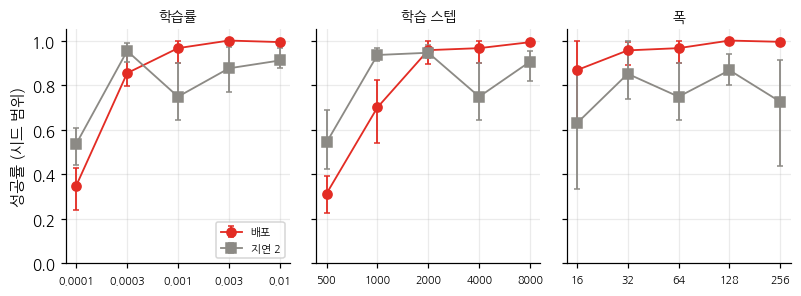

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(7.4, 2.8), sharey=True)
for a, (ax, vals) in zip(axs, AXES.items()):
    for c, col, mk in (("배포", RED, "o"), ("지연 2", GREY, "s")):
        m = np.array([np.mean(run(dict(DEF, **{ax: v}))[c])
                      for v in vals])
        lo = m - np.array([min(run(dict(DEF, **{ax: v}))[c])
                           for v in vals])
        hi = np.array([max(run(dict(DEF, **{ax: v}))[c])
                       for v in vals]) - m
        a.errorbar(range(len(vals)), m, yerr=[lo, hi], color=col,
                   marker=mk, capsize=2, lw=1.2, label=c)
    a.set_xticks(range(len(vals)))
    a.set_xticklabels([f"{v:g}" for v in vals], fontsize=7)
    a.set_title({"lr": "학습률", "steps": "학습 스텝",
                 "width": "폭"}[ax], fontsize=9)
axs[0].set_ylabel("성공률 (시드 범위)")
axs[0].set_ylim(0, 1.05)
axs[0].legend(fontsize=7, loc="lower right")
plt.tight_layout()
plt.show()

## 손잡이의 효과와 시드 편차

손잡이 하나가 성적을 얼마나 움직이는지를 **설정 사이 평균의 폭**으로 재고, 같은 설정 안에서 시드가 만드는 폭(설정마다의 최대−최소를 평균한 것)과 나란히 놓는다. 손잡이의 효과가 시드 편차보다 작으면, 그 손잡이를 훑는 일은 잡음을 훑는 일이다.

In [12]:
print(pad("축", 8) + pad("조건", 8) + pad("설정 사이 폭", 14, True)
      + pad("시드 폭 평균", 14, True) + pad("비", 7, True))
EFFECT = {}
for ax, vals in AXES.items():
    for c in EVC:
        rs = [run(dict(DEF, **{ax: v}))[c] for v in vals]
        between = np.ptp([np.mean(r) for r in rs])
        within = np.mean([np.ptp(r) for r in rs])
        EFFECT[(ax, c)] = (between, within)
        print(pad(ax, 8) + pad(c, 8)
              + pad(f"{between:.3f}", 14, True)
              + pad(f"{within:.3f}", 14, True)
              + pad(f"{between / within:.1f}", 7, True))

축      조건      설정 사이 폭  시드 폭 평균     비
lr      배포             0.651         0.093    7.0
lr      지연 2           0.417         0.161    2.6
steps   배포             0.680         0.134    5.1
steps   지연 2           0.403         0.155    2.6
width   배포             0.133         0.118    1.1
width   지연 2           0.238         0.332    0.7


## 훑기인가, 시연인가

훑기에 쓴 계산으로 무엇을 더 할 수 있었는가. 시뮬레이터에서는 시연을 모으는 비용이 거의 0이라 계산 시간으로 비교하면 불공평하다. 실기에서 시연 한 판은 사람의 시간이고, 하이퍼파라미터 훑기는 기계의 시간이다. 그래서 두 비용을 **각자의 단위**로 적고 성적만 같은 자로 잰다.

- **훑기** — 위에서 훑은 설정 가운데 배포 평균이 가장 높은 것 (원래 데이터 128판)
- **시연 두 배** — 기본 설정 그대로, 잡음 주입 시연 128판을 더 모아 256판

In [13]:
best_key = max(RUN, key=lambda k: np.mean(RUN[k]["배포"]))
best = RUN[best_key]["cfg"]
X2, Y2, _ = dart_eps(128, seed=2)
XD = np.concatenate([XN, nz(X2)])
YD = np.concatenate([YS, Y2])
r_def = run(DEF)
r_best = RUN[best_key]
r_data = run(DEF, XD, YD, tag="data x2")
print("훑기 최선 설정:", best)
print()
print(pad("선택", 22) + pad("배포", 20, True)
      + pad("지연 2", 20, True) + pad("비용", 22, True))
for nm, r, cost in (("기본값 · 128판", r_def, "—"),
                    ("훑기 최선 · 128판", r_best,
                     f"학습 {SWEEP_N}회 · {SWEEP_SEC:.0f}s"),
                    ("기본값 · 256판", r_data, "시연 128판")):
    print(pad(nm, 22) + pad(rng_s(r["배포"]), 20, True)
          + pad(rng_s(r["지연 2"]), 20, True) + pad(cost, 22, True))

훑기 최선 설정: {'lr': 0.003, 'steps': 4000, 'width': 64}

선택                                  배포              지연 2                  비용
기본값 · 128판          0.966 [0.90, 1.00]  0.748 [0.64, 0.90]                     —
훑기 최선 · 128판       1.000 [1.00, 1.00]  0.875 [0.77, 0.97]      학습 39회 · 206s
기본값 · 256판          0.978 [0.96, 0.99]  0.937 [0.90, 0.99]            시연 128판


## 설정을 고정한다

규칙을 코드로 적는다. **기본값을 유지하되, 배포 평균이 기본값의 시드 범위 최댓값을 넘는 설정이 있으면 그것으로 바꾼다.** 시드 범위 안에서의 개선은 개선으로 치지 않는다.

In [14]:
top_def = max(r_def["배포"])
better = [k for k in RUN if k != "data x2"
          and np.mean(RUN[k]["배포"]) > top_def]
pick = DEF
if better:
    top = max(better, key=lambda k: np.mean(RUN[k]["배포"]))
    pick = RUN[top]["cfg"]
HP = {"pick": pick, "default": DEF,
      "rule": "배포 평균 > 기본값 시드 범위 최댓값일 때만 교체",
      "sweep_sec": round(SWEEP_SEC, 1),
      "effect": {f"{a}/{c}": [round(float(b), 3),
                               round(float(w), 3)]
                 for (a, c), (b, w) in EFFECT.items()}}
os.makedirs("policy", exist_ok=True)
with open("policy/hparams.json", "w") as f:
    json.dump(HP, f, ensure_ascii=False, indent=1)
save_log("report/ch08_log.csv", LOG)
print(f"기본값 시드 범위 최댓값 {top_def:.3f}")
print(f"그보다 높은 설정: {len(better)}개")
print("고른 설정:", pick)
print()
print("남긴 산출물")
print("  policy/hparams.json   고른 설정·규칙·축별 효과")
print(f"  report/ch08_log.csv   판별 로그 {len(LOG):,}줄")

기본값 시드 범위 최댓값 1.000
그보다 높은 설정: 0개
고른 설정: {'lr': 0.001, 'steps': 4000, 'width': 64}

남긴 산출물
  policy/hparams.json   고른 설정·규칙·축별 효과
  report/ch08_log.csv   판별 로그 25,579줄


## 정리

**훑을 손잡이와 훑지 않을 손잡이가 있다.** 학습률과 스텝 수의 효과는 시드 편차의 5~7배이고, 폭의 효과는 시드 편차 수준이다.

**배포에서 같은 설정이 지연에서 갈린다.** 배포 0.96~1.00의 설정들이 지연 2에서는 0.75에서 0.95까지 갈렸다. 기본값이 골짜기에 놓였는데, 설정 탓인지 시드 탓인지는 가르지 못했다. 배포만 보고 고르면 지연 조건의 결과는 운에 맡겨진다.

**한계 수익은 조건에 따라 순위가 바뀐다.** 배포 조건에서는 훑기도 시연 두 배도 시드 범위 안이다. 지연 2에서는 시연 두 배(0.937)가 훑기 최선(0.875)보다 크다.

**고른 설정은 기본값이다.** `policy/hparams.json` 에 규칙과 축별 효과를 적었다.